D:\Miniconda3\envs\futurama\lib\site-packages\brainflow\board_shim.py:184: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


NEUROVOICE BCI SYSTEM
Brain Signals + Android Control
Helping Disabled People!
Built by Sachin Sharma

Unlocking Phone...


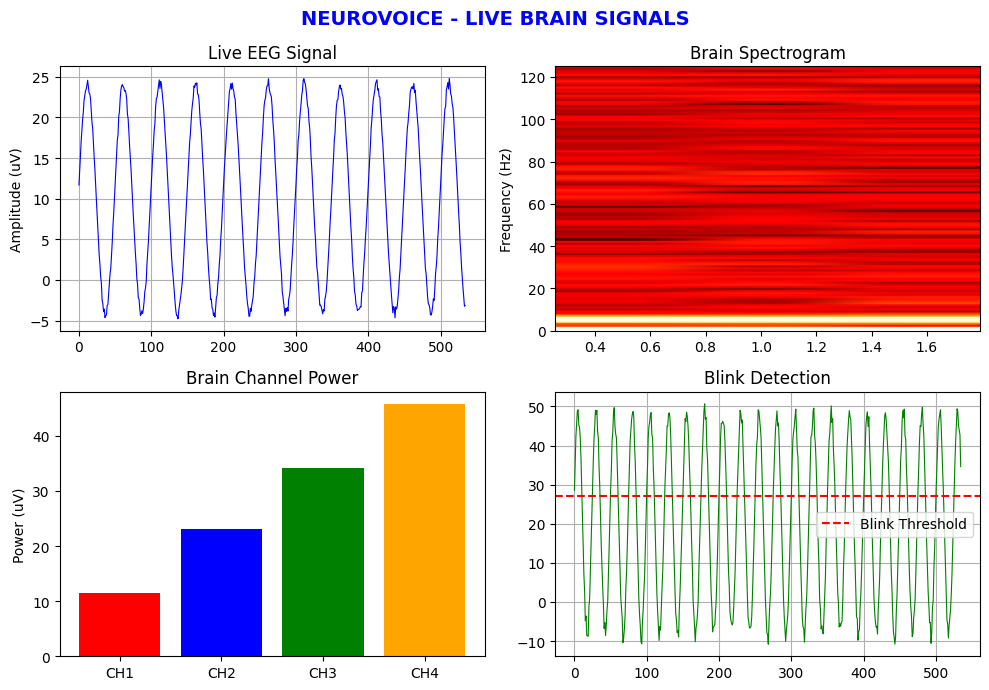

Brain Power: 28.62 uV


<Figure size 640x480 with 0 Axes>

Brain Power: 28.52 uV


<Figure size 640x480 with 0 Axes>

Brain Power: 28.5 uV


...

Brain Power: 28.24 uV


<Figure size 640x480 with 0 Axes>

Brain Power: 28.51 uV


<Figure size 640x480 with 0 Axes>

Brain Power: 28.5 uV
Call Done!

SMS...
SMS Done!

WhatsApp...
WhatsApp Done!

Instagram Reels...
  Reel 1/3!
  Reel 2/3!
  Reel 3/3!
Instagram Done!

YouTube Shorts...
YouTube Done!
NEUROVOICE DEMO COMPLETE!
Brain Signals    - Analyzed!
Android Phone    - Controlled!
Disabled People  - Helped!
Built by Sachin Sharma!


In [1]:
import uiautomator2 as u2
import subprocess
import time
import numpy as np
import matplotlib.pyplot as plt
from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds
import threading

d = u2.connect()

def adb(cmd):
    subprocess.run(['adb','shell'] + cmd.split())

def wait(sec):
    time.sleep(sec)

def typ(text):
    subprocess.run(['adb','shell','am','broadcast',
                   '-a','ADB_INPUT_TEXT','--es','msg',text])
    wait(0.5)

params = BrainFlowInputParams()
board_id = BoardIds.SYNTHETIC_BOARD.value
board = BoardShim(board_id, params)
board.prepare_session()
board.start_stream()
wait(2)

print("="*50)
print("NEUROVOICE BCI SYSTEM")
print("Brain Signals + Android Control")
print("Helping Disabled People!")
print("Built by Sachin Sharma")
print("="*50)

def show_eeg():
    plt.ion()
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle('NEUROVOICE - LIVE BRAIN SIGNALS',
                fontsize=14, color='blue', fontweight='bold')
    for step in range(10):
        data = board.get_board_data()
        eeg = BoardShim.get_eeg_channels(board_id)
        if data.shape[1] > 50:
            axes[0,0].clear()
            axes[0,0].plot(data[eeg[0]], 'b-', linewidth=0.8)
            axes[0,0].set_title('Live EEG Signal')
            axes[0,0].set_ylabel('Amplitude (uV)')
            axes[0,0].grid(True)

            axes[0,1].clear()
            axes[0,1].specgram(data[eeg[0]], Fs=250, cmap='hot')
            axes[0,1].set_title('Brain Spectrogram')
            axes[0,1].set_ylabel('Frequency (Hz)')

            axes[1,0].clear()
            powers = [np.mean(np.abs(data[eeg[i]]))
                     for i in range(min(4,len(eeg)))]
            colors = ['red','blue','green','orange']
            axes[1,0].bar(['CH1','CH2','CH3','CH4'],
                         powers, color=colors)
            axes[1,0].set_title('Brain Channel Power')
            axes[1,0].set_ylabel('Power (uV)')

            axes[1,1].clear()
            axes[1,1].plot(data[eeg[1]], 'g-', linewidth=0.8)
            axes[1,1].axhline(y=27, color='r',
                             linestyle='--',
                             label='Blink Threshold')
            axes[1,1].set_title('Blink Detection')
            axes[1,1].legend()
            axes[1,1].grid(True)

            plt.tight_layout()
            plt.pause(0.1)

            avg = round(np.mean(powers), 2)
            print(f"Brain Power: {avg} uV")
        wait(2)
    plt.ioff()

eeg_thread = threading.Thread(target=show_eeg)
eeg_thread.daemon = True
eeg_thread.start()
wait(3)

print("\nUnlocking Phone...")
adb('input keyevent KEYCODE_WAKEUP')
wait(1)
d.swipe(0.5,0.85,0.5,0.4,duration=0.5)
wait(3)
print("  Face Unlock...")
adb('input text 1111')
wait(0.5)
adb('input keyevent KEYCODE_ENTER')
wait(2)
print("Phone Unlocked!")

print("\nCalling...")
adb('am start -a android.intent.action.CALL -d tel:+918906233009')
wait(10)
adb('input keyevent KEYCODE_ENDCALL')
wait(2)
d.press('home')
wait(2)
print("Call Done!")

print("\nSMS...")
adb('am start -a android.intent.action.SENDTO -d sms:+918906233009')
wait(3)
if d(className='android.widget.EditText').exists(timeout=3):
    d(className='android.widget.EditText').click()
    wait(1)
    typ('Hello')
    wait(1)
if d(resourceId='com.google.android.apps.messaging:id/send_message_button').exists(timeout=2):
    d(resourceId='com.google.android.apps.messaging:id/send_message_button').click()
else:
    adb('input keyevent KEYCODE_ENTER')
wait(1)
d.press('home')
wait(1)
print("SMS Done!")

print("\nWhatsApp...")
d.app_start('com.whatsapp')
wait(3)
if d(description='Search').exists(timeout=2):
    d(description='Search').click()
wait(1)
typ('8906233009')
wait(1)
try:
    d(textContains='8906').click()
except:
    d(resourceId='com.whatsapp:id/contact_row_container').click()
wait(1)
if d(resourceId='com.whatsapp:id/entry').exists(timeout=2):
    d(resourceId='com.whatsapp:id/entry').click()
    wait(0.5)
    typ('Hello')
    wait(0.5)
if d(resourceId='com.whatsapp:id/send').exists(timeout=1):
    d(resourceId='com.whatsapp:id/send').click()
wait(1)
d.press('home')
wait(1)
print("WhatsApp Done!")

print("\nInstagram Reels...")
d.app_start('com.instagram.android')
wait(5)
if d(description='Reels').exists(timeout=3):
    d(description='Reels').click()
    wait(3)
for i in range(3):
    wait(3)
    d.swipe(0.5,0.75,0.5,0.25,duration=0.5)
    wait(2)
    print(f"  Reel {i+1}/3!")
d.press('home')
wait(2)
print("Instagram Done!")

print("\nYouTube Shorts...")
d.app_start('com.google.android.youtube')
wait(5)
if d(description='Shorts').exists(timeout=3):
    d(description='Shorts').click()
    wait(3)
    d.click(0.5,0.5)
    wait(10)
d.press('home')
wait(2)
print("YouTube Done!")

board.stop_stream()
board.release_session()

print("="*50)
print("NEUROVOICE DEMO COMPLETE!")
print("Brain Signals    - Analyzed!")
print("Android Phone    - Controlled!")
print("Disabled People  - Helped!")
print("Built by Sachin Sharma!")